# Does the winner usually play more aces?

### It imports two libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

#### It reads the match statistics and the `winner_code` column (the winner of each match)

In [2]:
IN_DIR = "cleaned_data"

stats_df = pd.read_parquet(f"{IN_DIR}/statistics.parquet")
event =pd.read_parquet(f"{IN_DIR}/event.parquet")[["match_id", "winner_code"]]

#### It retains only the 'ace' rows for the entire competition and merges them with the winner information
#### competitions with no clear winner are discarded

In [3]:
aces = stats_df[(stats_df["statistic_name"] == "aces") & (stats_df["period"] == "ALL")][["match_id", "home_value", "away_value"]]
m = aces.merge(event, on="match_id", how="inner").dropna(subset=["winner_code"])

#### For each match, it separately calculates the winning ace and the losing ace

In [4]:
m = m[m["winner_code"].isin([1, 2])]
winner_aces = m.apply(lambda r: r.home_value if r.winner_code == 1 else r.away_value, axis=1)
loser_aces = m.apply(lambda r: r.away_value if r.winner_code == 1 else r.home_value, axis=1)

means = [winner_aces.mean(), loser_aces.mean()]

print("Winner mean aces:", winner_aces.mean(), "| Loser mean aces:", loser_aces.mean())

Winner mean aces: 3.159942911512845 | Loser mean aces: 2.182778306374881


#### A simple bar chart with two bars (green for the winner, red for the loser) is drawn, with the exact value displayed on each bar

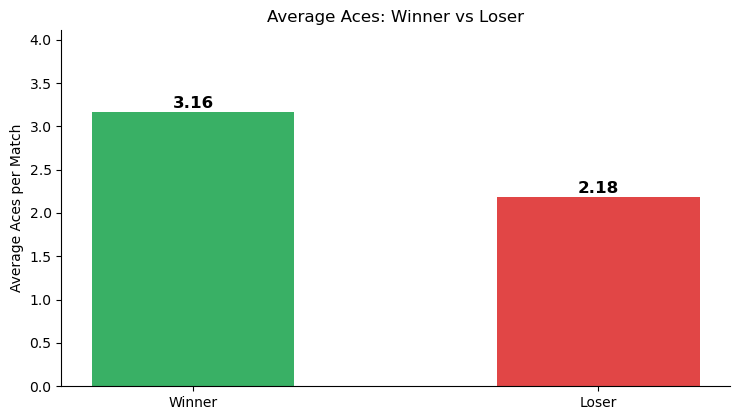

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 4.3))
bars = ax.bar(["Winner", "Loser"], means, color=["#16a34a", "#dc2626"], alpha=0.85, width=0.5)
for b, v in zip(bars, means):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.05, f"{v:.2f}", ha="center", fontsize=12, fontweight="bold")
ax.set_title("Average Aces: Winner vs Loser")
ax.set_ylabel("Average Aces per Match")
ax.set_ylim(0, max(means) * 1.3)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig("charts/more_aces_winner_vs_loser.png", dpi=170)
plt.show()

The average ace count for winners is 3.16, which is approximately 45% higher than the 2.18 average for losers.

However, this pattern does not hold true for every match: winners recorded more aces in only 49.9% of matches, while ace counts were tied in 23% of cases. In the remaining 27%, the loser actually hit more aces but still lost the match; consequently, the number of aces alone is not a definitive predictor of the outcome.

In short, while winners do average more aces, this represents a general statistical advantage rather than an absolute rule for every match.

(Matches where the winner was unknown—i.e., the `winner_code` was missing—were excluded from the analysis to avoid making assumptions about the outcome.)